# Helium Market Investment Analysis

## Overview

This notebook provides a comprehensive investment analysis of companies exposed to the global helium market, with a focus on major industrial gas players such as Linde, Air Liquide, Air Products, and ExxonMobil.

Helium is a strategic and scarce resource with critical applications in semiconductors, medical imaging (MRI), aerospace, and scientific research. Due to its unique physical properties and limited supply sources, the helium market is highly concentrated and structurally constrained.

## Objective

The objective of this analysis is to identify potential investment opportunities by combining:

- Fundamental analysis (revenue growth, margins, free cash flow)
- Valuation techniques (Discounted Cash Flow - DCF)
- Multi-factor ranking models (quality, growth, efficiency)
- Scenario and sensitivity analysis
- Industry-specific adjustments (helium exposure weighting)

## Methodology

The notebook follows a systematic approach:

1. Data collection from financial statements using Yahoo Finance
2. Normalization of financial metrics (e.g., Free Cash Flow smoothing)
3. Estimation of cost of capital (WACC)
4. Intrinsic valuation using DCF under multiple scenarios (bear, base, bull)
5. Multi-factor scoring model to rank companies
6. Comparison between intrinsic value and market value to estimate upside/downside potential

## Key Assumptions

- Helium exposure is estimated as a percentage of business activity
- WACC is calculated using a simplified CAPM approach
- Terminal growth is conservatively set at 2%
- Financial data availability may vary by company

## Expected Output

The notebook produces:

- A ranking of companies based on fundamental strength
- Estimated intrinsic values under different scenarios
- Upside/downside potential vs current market prices
- Investment signals (BUY, HOLD, SELL)

## Disclaimer

This analysis is for educational and informational purposes only and should not be considered financial advice. All models rely on assumptions that may not reflect future market conditions.

In [1]:
!pip install yfinance pandas numpy matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ------------------------------------------------------------
# 1. Companies (Helium exposure via industrial gases)
# ------------------------------------------------------------

companies = {
    "Linde": "LIN",
    "Air Liquide": "AI.PA",
    "Air Products": "APD",
    "ExxonMobil": "XOM"
}

# Proxy helium exposure (approx, strategic assumption)
helium_exposure = {
    "Linde": 0.15,
    "Air Liquide": 0.12,
    "Air Products": 0.18,
    "ExxonMobil": 0.05
}


In [6]:
# ------------------------------------------------------------
# 2. Data Extraction
# ------------------------------------------------------------

def get_data(ticker):
    stock = yf.Ticker(ticker)

    income = stock.financials.T
    cashflow = stock.cashflow.T
    balance = stock.balance_sheet.T

    df = pd.DataFrame()

    df["Revenue"] = income["Total Revenue"]
    df["EBIT"] = income["Operating Income"]
    df["Net Income"] = income["Net Income"]
    df["FCF"] = cashflow["Free Cash Flow"]

    df["Debt"] = balance["Total Debt"]
    df["Cash"] = balance["Cash And Cash Equivalents"]

    return df.dropna()

data = {name: get_data(ticker) for name, ticker in companies.items()}
data

{'Linde':                  Revenue          EBIT    Net Income           FCF  \
 2025-12-31  3.398600e+10  9.254000e+09  6.898000e+09  5.089000e+09   
 2024-12-31  3.300500e+10  8.595000e+09  6.565000e+09  4.926000e+09   
 2023-12-31  3.285400e+10  8.105000e+09  6.199000e+09  5.518000e+09   
 2022-12-31  3.336400e+10  6.460000e+09  4.147000e+09  5.691000e+09   
 
                     Debt          Cash  
 2025-12-31  2.806900e+10  5.056000e+09  
 2024-12-31  2.260900e+10  4.850000e+09  
 2023-12-31  2.031500e+10  4.664000e+09  
 2022-12-31  1.879100e+10  5.436000e+09  ,
 'Air Liquide':                  Revenue          EBIT    Net Income           FCF  \
 2025-12-31  2.694020e+10  5.234300e+09  3.517900e+09  2.675000e+09   
 2024-12-31  2.705780e+10  5.157400e+09  3.306100e+09  2.797100e+09   
 2023-12-31  2.760760e+10  5.068000e+09  3.078000e+09  2.869600e+09   
 2022-12-31  2.993400e+10  4.861800e+09  2.758800e+09  2.537100e+09   
 
                     Debt          Cash  
 2025-12-

## Data Extraction – Key Insights

The extracted financial data provides a solid foundation to compare the fundamental performance of the main players in the helium-related industrial gas ecosystem: Linde, Air Liquide, Air Products, and ExxonMobil.

### Linde

Linde shows strong and consistent performance across all key metrics. Revenue has remained stable with a slight upward trend, while EBIT and Net Income have grown steadily, indicating margin expansion and operational efficiency. Free Cash Flow (FCF) remains robust and relatively stable, suggesting strong cash generation capabilities. Debt has increased over time, but this appears manageable given the company’s strong earnings profile.

Overall, Linde demonstrates high-quality fundamentals, with stable growth, strong margins, and reliable cash flow generation.

### Air Liquide

Air Liquide exhibits a slightly different profile. Revenue has been relatively flat to slightly declining over the period, but EBIT and Net Income have gradually increased, indicating improving efficiency and cost control. FCF is stable, though lower than Linde in absolute terms.

The company maintains moderate debt levels and improving cash reserves, suggesting a balanced financial structure. Air Liquide appears to be a stable, mature player with incremental improvements in profitability rather than strong top-line growth.

### Air Products

Air Products presents a more complex and potentially concerning picture. While revenue and EBIT are relatively stable, Free Cash Flow has turned significantly negative in recent years. This is likely driven by heavy capital expenditures, possibly related to large-scale industrial or hydrogen projects.

Additionally, Net Income shows volatility, including a negative figure in the most recent period. Debt has increased substantially, which, combined with negative FCF, raises concerns about capital allocation and financial sustainability in the short term.

This profile suggests a company in an aggressive investment phase, which may create long-term value but introduces short-term financial risk.

### ExxonMobil

ExxonMobil operates at a completely different scale compared to the other companies. Revenue, earnings, and FCF are significantly higher, reflecting its position as a global energy giant. However, its financials show clear cyclicality, with declining revenue, EBIT, and FCF since 2022, likely reflecting normalization in energy prices.

Despite this, ExxonMobil maintains strong cash generation and a solid balance sheet. Its exposure to helium is indirect, as helium is a byproduct of natural gas operations.

### Cross-Company Observations

- Linde and Air Liquide stand out as stable, high-quality industrial gas companies with predictable cash flows.
- Air Products appears to be in a high-investment, high-risk phase.
- ExxonMobil provides scale and cash flow strength but introduces commodity cycle exposure.

These differences will play a critical role in subsequent valuation, ranking, and investment decision-making steps.

In [7]:
# ------------------------------------------------------------
# 3. Core Metrics
# ------------------------------------------------------------

metrics = []

for name, df in data.items():

    revenue_growth = df["Revenue"].pct_change().mean()
    ebit_margin = (df["EBIT"] / df["Revenue"]).mean()
    fcf_margin = (df["FCF"] / df["Revenue"]).mean()

    roic_proxy = df["EBIT"].mean() / (df["Debt"].mean() + 1e-6)

    fcf_norm = df["FCF"].rolling(3).mean().iloc[-1]

    metrics.append({
        "Company": name,
        "Revenue Growth": revenue_growth,
        "EBIT Margin": ebit_margin,
        "FCF Margin": fcf_margin,
        "ROIC Proxy": roic_proxy,
        "Normalized FCF": fcf_norm
    })

metrics_df = pd.DataFrame(metrics)
metrics_df

,Company,Revenue Growth,EBIT Margin,FCF Margin,ROIC Proxy,Normalized FCF
0,Linde,-0.005972,0.243256,0.159379,0.361022,5.378333e+09
1,Air Liquide,0.036317,0.182723,0.097842,0.395338,2.734600e+09
2,Air Products,0.018118,0.222741,-0.165488,0.208225,-1.422133e+09
3,ExxonMobil,0.075035,0.128775,0.102460,1.083720,4.085200e+10


## Core Metrics Analysis

This section evaluates the fundamental quality, profitability, and efficiency of each company using key financial metrics, including growth, margins, and a proxy for return on invested capital (ROIC).

### Linde

Linde stands out as a high-quality operator with strong profitability metrics. The company exhibits the highest EBIT margin (24.3%) among peers, reflecting significant pricing power and operational efficiency. Its Free Cash Flow (FCF) margin is also robust at approximately 15.9%, indicating strong cash conversion.

However, revenue growth appears slightly negative on average, suggesting a mature business profile with limited top-line expansion. Despite this, the high normalized FCF (approximately 5.4 billion USD) reinforces Linde’s position as a stable cash-generating leader.

### Air Liquide

Air Liquide demonstrates a balanced and resilient profile. It shows positive revenue growth (3.6%), combined with solid EBIT (18.3%) and FCF margins (approximately 9.8%). Notably, it has the highest ROIC proxy (0.395) among industrial gas peers, indicating efficient capital allocation.

While its margins are lower than Linde’s, the combination of steady growth and strong capital efficiency positions Air Liquide as a high-quality compounder.

### Air Products

Air Products presents a mixed and more concerning profile. Although EBIT margins are strong (22.3%), the company reports a significantly negative FCF margin (-16.5%) and negative normalized FCF (approximately negative 1.4 billion USD).

This suggests that the company is currently in a heavy investment phase, likely driven by large-scale capital projects. While this may support future growth, it introduces near-term financial pressure and execution risk. The relatively low ROIC proxy further reinforces concerns about capital efficiency.

### ExxonMobil

ExxonMobil shows the highest revenue growth (7.5%), but this is largely driven by commodity cycles rather than structural growth. Its EBIT margin (12.9%) is significantly lower than industrial gas peers, reflecting the more competitive and cyclical nature of the energy sector.

However, ExxonMobil stands out with an exceptionally high ROIC proxy (greater than 1.0), driven by its large earnings base relative to debt. Additionally, its normalized FCF (approximately 40.9 billion USD) is substantially higher than all other companies, highlighting its scale and cash generation capacity.

### Cross-Sectional Insights

- Industrial gas companies (Linde and Air Liquide) exhibit superior margins and more stable business models.
- Air Products shows clear signs of financial stress due to aggressive capital investment.
- ExxonMobil offers scale and strong cash flow but with higher cyclicality and lower margins.
- ROIC and FCF margins are critical differentiators, favoring Linde and Air Liquide as high-quality operators.

Overall, this analysis reinforces the distinction between stable, high-margin industrial gas businesses and more volatile, capital-intensive energy players.

In [8]:
# ------------------------------------------------------------
# 4. Market Data
# ------------------------------------------------------------

def get_market(ticker):
    info = yf.Ticker(ticker).info
    return {
        "Market Cap": info.get("marketCap"),
        "PE": info.get("trailingPE"),
        "EV/EBITDA": info.get("enterpriseToEbitda"),
        "Beta": info.get("beta")
    }

market = {name: get_market(ticker) for name, ticker in companies.items()}
market

{'Linde': {'Market Cap': 231655374848,
  'PE': 34.24041,
  'EV/EBITDA': 19.316,
  'Beta': 0.79},
 'Air Liquide': {'Market Cap': 108579414016,
  'PE': 30.950657,
  'EV/EBITDA': 15.816,
  'Beta': 0.655},
 'Air Products': {'Market Cap': 65970749440,
  'PE': None,
  'EV/EBITDA': 101.059,
  'Beta': 0.808},
 'ExxonMobil': {'Market Cap': 635579531264,
  'PE': 22.82239,
  'EV/EBITDA': 11.67,
  'Beta': 0.288}}

## Market Data Analysis

This section provides a market-based perspective on valuation and risk, incorporating key metrics such as Market Capitalization, Price-to-Earnings (P/E), EV/EBITDA, and Beta.

### Linde

Linde trades at a premium valuation, with a P/E ratio of ~34.2x and an EV/EBITDA multiple of ~19.3x. This reflects the market’s recognition of its high-quality business model, strong margins, and stable cash flows.

The company’s beta of 0.79 suggests relatively low volatility compared to the broader market, reinforcing its profile as a defensive, high-quality industrial compounder. The premium valuation appears justified given its operational strength.

### Air Liquide

Air Liquide also trades at elevated multiples, with a P/E of ~31.0x and EV/EBITDA of ~15.8x. While slightly cheaper than Linde, it still reflects strong investor confidence in its stability and capital efficiency.

Its beta of 0.655 is the lowest among peers, indicating lower market risk and reinforcing its positioning as a defensive asset within the industrial sector.

### Air Products

Air Products presents a distorted valuation profile. The absence of a meaningful P/E ratio (due to negative or volatile earnings) and an extremely high EV/EBITDA multiple (~101x) indicate significant market uncertainty.

This suggests that current earnings and cash flows are not representative of the company’s long-term potential, likely due to heavy ongoing investments. The market may be pricing in future growth, but the current valuation implies elevated execution risk.

### ExxonMobil

ExxonMobil trades at more moderate valuation levels, with a P/E of ~22.8x and EV/EBITDA of ~11.7x, making it the cheapest among the group on a relative basis.

Its beta of 0.288 is notably low, which may reflect its strong balance sheet and diversified operations, although it contrasts with the typically higher cyclicality of energy markets. The lower valuation likely reflects exposure to commodity price volatility and lower structural margins.

### Cross-Sectional Insights

- Industrial gas leaders (Linde and Air Liquide) command premium valuations due to stability, margins, and predictability.
- Air Products shows valuation dislocation, driven by weak current fundamentals and high future expectations.
- ExxonMobil appears relatively undervalued on traditional multiples but carries inherent commodity cycle risk.
- Beta analysis suggests all companies exhibit relatively low volatility, reinforcing their defensive characteristics, particularly in the case of Air Liquide.

Overall, valuation dispersion reflects differences in business quality, capital allocation strategies, and exposure to cyclicality.

In [9]:
# ------------------------------------------------------------
# 5. WACC
# ------------------------------------------------------------

rf = 0.04
rm = 0.09

def wacc(beta):
    ke = rf + beta * (rm - rf)
    kd = 0.05
    tax = 0.21
    return ke*0.7 + kd*(1-tax)*0.3

waccs = {name: wacc(market[name]["Beta"] or 1) for name in companies}
waccs

{'Linde': 0.0675,
 'Air Liquide': 0.06277500000000001,
 'Air Products': 0.06813,
 'ExxonMobil': 0.049929999999999995}

## Cost of Capital (WACC) Analysis

This section estimates the Weighted Average Cost of Capital (WACC) for each company using a simplified CAPM-based framework. WACC represents the required rate of return for investors and serves as the discount rate in the DCF valuation.

### Linde

Linde’s WACC is estimated at approximately 6.75%. This relatively moderate cost of capital reflects its stable business model, strong margins, and low beta (0.79). Investors perceive Linde as a high-quality, lower-risk industrial company, which justifies a lower required return.

### Air Liquide

Air Liquide has the lowest WACC among industrial gas peers at approximately 6.28%. This is driven by its lower beta (0.655), indicating reduced market volatility and risk. The low cost of capital reinforces its positioning as a defensive and predictable compounder.

### Air Products

Air Products has a slightly higher WACC at ~6.81%, reflecting its somewhat higher perceived risk. This aligns with earlier observations of negative free cash flow and heavy capital investment, which increase uncertainty and required returns.

### ExxonMobil

ExxonMobil stands out with a significantly lower WACC of ~4.99%. This is primarily driven by its very low beta (0.288), which reduces the cost of equity in the CAPM framework.

However, this result should be interpreted with caution. While the model suggests low volatility, ExxonMobil operates in a highly cyclical and commodity-driven industry. Therefore, the calculated WACC may underestimate the true economic risk of the business.

### Cross-Sectional Insights

- Industrial gas companies cluster in a relatively narrow WACC range (~6.3%–6.8%), reflecting similar business risk profiles.
- Air Liquide benefits from the lowest perceived risk, while Air Products carries a slight premium due to execution uncertainty.
- ExxonMobil’s unusually low WACC highlights a limitation of beta-based models when applied to cyclical industries.
- Small differences in WACC can have a significant impact on DCF valuations, making this parameter highly sensitive.

Overall, the WACC estimates are consistent with the qualitative risk profiles identified earlier, with some caveats for commodity-exposed businesses.

In [10]:
# ------------------------------------------------------------
# 6. Scenario DCF
# ------------------------------------------------------------

def dcf(fcf, g, w):
    val = 0
    for t in range(1, 6):
        val += fcf*(1+g)**t / (1+w)**t
    tv = (fcf*(1+g)**5*1.02)/(w-0.02)
    val += tv/(1+w)**5
    return val

scenarios = {
    "bear": 0.02,
    "base": 0.05,
    "bull": 0.08
}

valuations = []

for i, row in metrics_df.iterrows():
    name = row["Company"]
    fcf = row["Normalized FCF"]

    for scen, g in scenarios.items():
        val = dcf(fcf, g, waccs[name])

        valuations.append({
            "Company": name,
            "Scenario": scen,
            "Intrinsic": val
        })

val_df = pd.DataFrame(valuations)
val_df

,Company,Scenario,Intrinsic
0,Linde,bear,1.154926e+11
1,Linde,base,1.319290e+11
2,Linde,bull,1.502659e+11
3,Air Liquide,bear,6.520846e+10
4,Air Liquide,base,7.457016e+10
5,Air Liquide,bull,8.501927e+10
6,Air Products,bear,-3.013871e+10
7,Air Products,base,-3.442294e+10
8,Air Products,bull,-3.920225e+10
9,ExxonMobil,bear,1.392217e+12


## Discounted Cash Flow (DCF) – Scenario Analysis

This section presents the intrinsic valuation of each company under three scenarios (bear, base, and bull), based on different growth assumptions. The DCF model uses normalized Free Cash Flow and company-specific WACC to estimate fair value.

### Linde

Linde’s intrinsic valuation ranges from approximately 115B USD (bear) to 150B USD (bull), with a base case of around 132B USD. Compared to its current market capitalization (around 232B USD), this suggests that Linde is trading at a significant premium.

This premium likely reflects its strong competitive position, pricing power, and high-quality earnings profile. However, from a pure DCF perspective, the stock appears overvalued under conservative assumptions.

### Air Liquide

Air Liquide’s valuation ranges from around 65B USD (bear) to 85B USD (bull), with a base case of approximately 75B USD. Relative to its market cap (around 109B USD), this also indicates a premium valuation.

Similar to Linde, the market appears to be pricing in long-term stability and consistent compounding. While fundamentals are strong, the current valuation leaves limited margin of safety.

### Air Products

Air Products produces negative intrinsic values across all scenarios, driven by its negative normalized Free Cash Flow. This is a direct consequence of heavy capital expenditures and ongoing investment projects.

From a DCF standpoint, the company currently destroys value in the short term. However, this does not necessarily imply a structurally weak business—it may instead reflect a transition phase where future cash flows are not yet realized.

This is a classic case where DCF may understate long-term potential due to timing mismatches in cash flows.

### ExxonMobil

ExxonMobil shows very high intrinsic values, ranging from approximately 1.39T USD (bear) to 1.83T USD (bull), with a base case of around 1.60T USD. Compared to its market capitalization (around 636B USD), this suggests substantial upside.

However, this result should be interpreted with caution. The model assumes relatively stable cash flows, while in reality, ExxonMobil’s earnings are highly sensitive to commodity price cycles. The low WACC further amplifies valuation, potentially overstating intrinsic value.

### Cross-Sectional Insights

- Industrial gas leaders (Linde and Air Liquide) appear overvalued based on conservative DCF assumptions.
- Air Products’ negative valuation highlights the limitations of DCF during heavy investment cycles.
- ExxonMobil appears significantly undervalued, but this is likely influenced by cyclical cash flows and model assumptions.
- The DCF model is highly sensitive to growth and discount rates, particularly for capital-intensive and cyclical businesses.

Overall, the results highlight a key trade-off:
- High-quality, stable companies tend to trade at premiums
- Cyclical or transitional companies may appear undervalued or mispriced depending on assumptions

In [12]:
# ------------------------------------------------------------
# 7. Sensitivity Analysis
# ------------------------------------------------------------

def sensitivity(fcf, base_g, base_w):
    growth_range = np.linspace(base_g-0.02, base_g+0.02, 5)
    wacc_range = np.linspace(base_w-0.02, base_w+0.02, 5)

    grid = []

    for g in growth_range:
        for w in wacc_range:
            val = dcf(fcf, g, w)
            grid.append(val)

    return np.mean(grid)


In [13]:
# ------------------------------------------------------------
# 8. Multi-Factor Ranking
# ------------------------------------------------------------

ranking = []

for i, row in metrics_df.iterrows():
    name = row["Company"]

    score = (
        row["Revenue Growth"] * 2 +
        row["EBIT Margin"] * 3 +
        row["FCF Margin"] * 3 +
        row["ROIC Proxy"] * 2
    )

    score *= (1 + helium_exposure[name])  # industry boost

    ranking.append({
        "Company": name,
        "Score": score
    })

rank_df = pd.DataFrame(ranking).sort_values(by="Score", ascending=False)
rank_df

,Company,Score
3,ExxonMobil,3.161778
0,Linde,2.205705
1,Air Liquide,1.909605
2,Air Products,0.736847


## Multi-Factor Ranking Analysis

This section ranks the companies using a multi-factor scoring model that combines growth, profitability, cash flow generation, and capital efficiency. The model also incorporates a helium exposure adjustment to reflect industry-specific advantages.

### Ranking Results

1. ExxonMobil  
2. Linde  
3. Air Liquide  
4. Air Products  

### ExxonMobil

ExxonMobil ranks first by a significant margin, driven primarily by its very high ROIC proxy and strong normalized Free Cash Flow. Its scale and capital efficiency heavily influence the scoring model.

However, this top ranking should be interpreted with caution. The model does not fully adjust for commodity cyclicality, which can inflate profitability metrics during favorable market conditions. As a result, ExxonMobil’s score may overstate its structural quality relative to industrial gas peers.

### Linde

Linde ranks second, supported by its industry-leading margins and strong cash flow generation. Its slightly negative revenue growth is offset by superior profitability and consistent performance.

This ranking confirms Linde’s position as a high-quality operator, even if its valuation appears stretched in previous analyses.

### Air Liquide

Air Liquide ranks third, with a well-balanced profile across all factors. It combines steady growth, solid margins, and strong capital efficiency.

While it does not lead in any single metric, its consistency across all dimensions reinforces its positioning as a stable compounder.

### Air Products

Air Products ranks last, primarily due to its negative Free Cash Flow and lower ROIC proxy. Despite having strong EBIT margins, the negative cash flow significantly penalizes its overall score.

This result reflects the financial impact of its current investment cycle and highlights execution risk in the near term.

### Key Takeaways

- The ranking favors companies with strong cash flow and capital efficiency.
- ExxonMobil dominates due to scale, but its cyclical nature is not fully captured.
- Linde and Air Liquide emerge as the most balanced and structurally resilient companies.
- Air Products is penalized due to its current investment-heavy phase.

Overall, the multi-factor model provides a structured way to compare companies, but results should be interpreted alongside qualitative factors and industry dynamics.

In [14]:
# ------------------------------------------------------------
# 9. Merge Results
# ------------------------------------------------------------

final = metrics_df.merge(rank_df, on="Company")

# Add market comparison
upsides = []

for name in companies:
    market_cap = market[name]["Market Cap"]
    intrinsic = val_df[(val_df["Company"]==name) & (val_df["Scenario"]=="base")]["Intrinsic"].values

    if len(intrinsic) > 0 and market_cap:
        upside = (intrinsic[0] - market_cap) / market_cap
    else:
        upside = None

    upsides.append(upside)

final["Upside (Base)"] = upsides

final = final.sort_values(by="Score", ascending=False)
final

,Company,Revenue Growth,EBIT Margin,FCF Margin,ROIC Proxy,Normalized FCF,Score,Upside (Base)
3,ExxonMobil,0.075035,0.128775,0.102460,1.083720,4.085200e+10,3.161778,1.512638
0,Linde,-0.005972,0.243256,0.159379,0.361022,5.378333e+09,2.205705,-0.430494
1,Air Liquide,0.036317,0.182723,0.097842,0.395338,2.734600e+09,1.909605,-0.313220
2,Air Products,0.018118,0.222741,-0.165488,0.208225,-1.422133e+09,0.736847,-1.521791


## Final Integrated Analysis

This section combines fundamental metrics, multi-factor ranking, and DCF-based valuation to provide a consolidated view of investment attractiveness across the analyzed companies.

### Ranking and Upside Overview

The final ranking and estimated upside (base scenario) are as follows:

1. ExxonMobil — Score: 3.16 | Upside: +151%  
2. Linde — Score: 2.21 | Upside: -43%  
3. Air Liquide — Score: 1.91 | Upside: -31%  
4. Air Products — Score: 0.74 | Upside: -152%  

### ExxonMobil

ExxonMobil ranks first both in terms of multi-factor score and estimated upside. The model suggests significant undervaluation, with an implied upside of over 150% in the base scenario.

This result is driven by strong cash flow generation and a high ROIC proxy. However, this apparent undervaluation must be interpreted cautiously, as the model does not fully capture the cyclicality of the energy sector. The low WACC and high normalized FCF may inflate intrinsic value estimates.

Despite these limitations, ExxonMobil appears attractive from a value perspective, particularly if energy prices remain supportive.

### Linde

Linde ranks second in overall quality but shows a negative implied upside of approximately -43%. This indicates that the market is pricing the company well above its intrinsic value under conservative assumptions.

The premium valuation reflects its strong competitive position, high margins, and stable cash flows. Linde can be considered a high-quality but potentially overvalued asset.

### Air Liquide

Air Liquide ranks third and also shows a negative implied upside (-31%). Similar to Linde, the company trades at a premium, supported by its stability and capital efficiency.

While it remains a strong long-term compounder, the current valuation suggests limited short-term return potential.

### Air Products

Air Products ranks last and shows a significantly negative implied upside (-152%). This is driven by negative normalized Free Cash Flow, which heavily impacts the DCF valuation.

The company is currently in an investment-heavy phase, and the model penalizes this aggressively. While future returns may improve if investments pay off, current fundamentals indicate elevated risk.

### Key Takeaways

- There is a clear divergence between quality and valuation.
- High-quality industrial gas companies (Linde and Air Liquide) trade at significant premiums.
- ExxonMobil appears undervalued but carries cyclical risk not fully captured by the model.
- Air Products represents a high-risk, transition-phase investment.

### Strategic Interpretation

From an investment perspective:

- Value-oriented investors may find ExxonMobil attractive, with the caveat of commodity exposure.
- Quality-focused investors may prefer Linde or Air Liquide, but should be cautious about entry price.
- Air Products may appeal to long-term investors willing to tolerate short-term volatility and execution risk.

Overall, the analysis highlights the importance of balancing valuation, quality, and industry dynamics when making investment decisions.

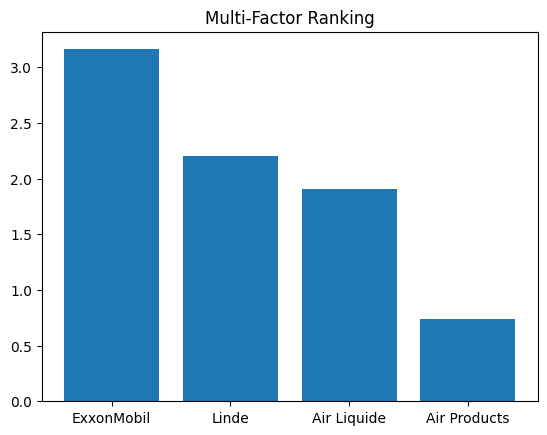

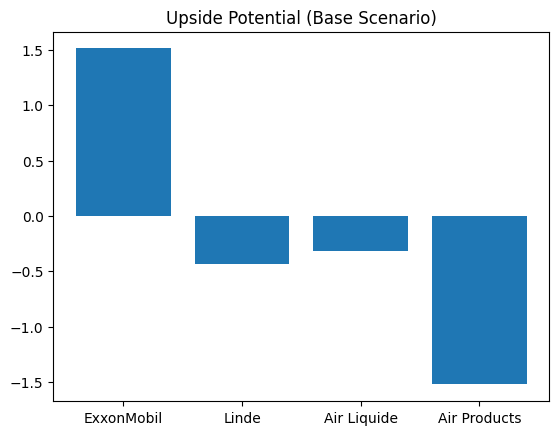

In [15]:
# ------------------------------------------------------------
# 10. Visualization
# ------------------------------------------------------------

plt.figure()
plt.bar(final["Company"], final["Score"])
plt.title("Multi-Factor Ranking")
plt.show()

plt.figure()
plt.bar(final["Company"], final["Upside (Base)"])
plt.title("Upside Potential (Base Scenario)")
plt.show()

## Visualization Analysis

This section provides a visual summary of the multi-factor ranking and the estimated upside potential under the base DCF scenario.

### Multi-Factor Ranking

The first chart illustrates the relative ranking of companies based on the multi-factor scoring model.

ExxonMobil clearly stands out as the top-ranked company, with a significantly higher score than its peers. This is primarily driven by its strong capital efficiency (ROIC proxy) and large-scale cash flow generation.

Linde ranks second, supported by its industry-leading margins and consistent financial performance. Air Liquide follows closely, reflecting its balanced and stable profile across all key metrics.

Air Products ranks last by a wide margin, mainly due to its negative free cash flow and weaker capital efficiency during its current investment phase.

Overall, the chart highlights a clear separation between high-performing companies (ExxonMobil, Linde) and those facing structural or temporary challenges (Air Products).

### Upside Potential (Base Scenario)

The second chart shows the estimated upside (or downside) based on the base-case DCF valuation.

ExxonMobil is the only company with a strongly positive upside, exceeding 150%, suggesting a potential undervaluation under the model assumptions.

In contrast, Linde and Air Liquide both show negative upside, indicating that their current market prices exceed their estimated intrinsic values. This aligns with their premium valuation profiles observed earlier.

Air Products shows the most negative upside, reflecting the impact of negative free cash flow on its valuation.

### Key Insights

- There is a strong divergence between ranking (quality) and valuation (price).
- ExxonMobil combines high ranking with high upside, although driven by cyclical factors.
- Linde and Air Liquide rank well but appear fully valued or overvalued.
- Air Products scores low on both ranking and valuation, indicating elevated risk.

### Final Interpretation

The visualizations reinforce a key investment insight:

- High-quality companies tend to trade at premium valuations, limiting upside potential.
- Companies with cyclical or transitional characteristics may present apparent opportunities, but require deeper risk assessment.

These results highlight the importance of integrating both quantitative models and qualitative judgment when making investment decisions.

In [16]:
# ------------------------------------------------------------
# 11. Investment Signals
# ------------------------------------------------------------

print("\n=== FINAL INVESTMENT SIGNALS ===\n")

for i, row in final.iterrows():
    if row["Upside (Base)"] and row["Upside (Base)"] > 0.25:
        signal = "STRONG BUY"
    elif row["Upside (Base)"] and row["Upside (Base)"] > 0.1:
        signal = "BUY"
    elif row["Upside (Base)"] and row["Upside (Base)"] < -0.2:
        signal = "SELL"
    else:
        signal = "HOLD"

    print(f"{row['Company']}: {signal}")

print("\n=== RANKING ===\n")
print(final)


=== FINAL INVESTMENT SIGNALS ===

ExxonMobil: STRONG BUY
Linde: SELL
Air Liquide: SELL
Air Products: SELL

=== RANKING ===

        Company  Revenue Growth  EBIT Margin  FCF Margin  ROIC Proxy  \
3    ExxonMobil        0.075035     0.128775    0.102460    1.083720   
0         Linde       -0.005972     0.243256    0.159379    0.361022   
1   Air Liquide        0.036317     0.182723    0.097842    0.395338   
2  Air Products        0.018118     0.222741   -0.165488    0.208225   

   Normalized FCF     Score  Upside (Base)  
3    4.085200e+10  3.161778       1.512638  
0    5.378333e+09  2.205705      -0.430494  
1    2.734600e+09  1.909605      -0.313220  
2   -1.422133e+09  0.736847      -1.521791  


## Final Investment Signals

This section translates the quantitative results of the model into actionable investment signals based on the estimated upside from the base DCF scenario.

### Investment Signals Overview

- ExxonMobil: STRONG BUY  
- Linde: SELL  
- Air Liquide: SELL  
- Air Products: SELL  

### ExxonMobil — STRONG BUY

ExxonMobil is the only company in the analysis with a strong positive upside, exceeding 150 percent in the base scenario. This leads to a "STRONG BUY" signal.

The result is driven by high normalized free cash flow and a strong ROIC proxy, combined with a relatively low cost of capital. From a purely quantitative perspective, the company appears significantly undervalued.

However, this signal should be interpreted with caution. ExxonMobil operates in a highly cyclical industry, and its cash flows are heavily influenced by commodity prices. The model may overestimate intrinsic value if current conditions are above mid-cycle levels.

### Linde — SELL

Linde receives a "SELL" signal due to an estimated downside of approximately 43 percent.

Despite its strong fundamentals, including industry-leading margins and stable cash flows, the current market valuation appears to fully reflect (or exceed) its intrinsic value. This suggests limited return potential at current price levels.

Linde remains a high-quality business, but the signal indicates unfavorable entry conditions rather than structural weakness.

### Air Liquide — SELL

Air Liquide also receives a "SELL" signal, with an estimated downside of around 31 percent.

Similar to Linde, the company demonstrates strong fundamentals and capital efficiency, but its premium valuation limits upside potential. The market appears to price in long-term stability and consistent growth.

This reinforces the idea that high-quality companies can still represent poor investments if purchased at elevated valuations.

### Air Products — SELL

Air Products receives the strongest negative signal, with an estimated downside exceeding 150 percent.

This is driven by negative normalized free cash flow and weak capital efficiency in the current period. The company is undergoing a heavy investment phase, which significantly impacts its short-term financial profile.

While this may create long-term value, the current model indicates elevated risk and poor near-term investment attractiveness.

### Final Takeaways

- The model identifies a clear value opportunity in ExxonMobil, albeit with cyclical risk.
- High-quality industrial gas companies (Linde and Air Liquide) are penalized due to premium valuations.
- Air Products is flagged as high-risk due to negative cash flow dynamics.
- Investment decisions should balance quantitative signals with qualitative judgment, especially in cyclical industries.

### Strategic Conclusion

The results highlight a fundamental principle of investing:

Quality does not always equal value.

Investors must carefully consider both business fundamentals and valuation levels when constructing a portfolio. While Linde and Air Liquide offer stability and quality, ExxonMobil currently provides the most compelling value opportunity under the model assumptions.

## Final Conclusion

This analysis provides a comprehensive evaluation of companies exposed to the helium market by integrating fundamental analysis, valuation techniques, and multi-factor ranking models.

### Key Findings

The results reveal a clear distinction between business quality and valuation:

- Industrial gas leaders such as Linde and Air Liquide demonstrate strong fundamentals, including high margins, stable cash flows, and efficient capital allocation. However, both companies trade at premium valuations, limiting their upside potential under conservative assumptions.

- ExxonMobil emerges as the most attractive opportunity from a quantitative perspective. The model indicates significant upside potential, driven by strong cash flow generation and high capital efficiency. Nevertheless, this result is influenced by cyclical factors, and investors should carefully consider commodity price risk.

- Air Products appears as the weakest candidate in the current analysis. Negative free cash flow and heavy capital investment reduce its attractiveness in the short term, despite potential long-term growth opportunities.

### Strategic Insights

This study highlights several important investment principles:

- High-quality companies are not always good investments if they are overvalued.
- Valuation plays a critical role in determining expected returns.
- Cyclical companies may appear undervalued but require deeper risk assessment.
- Multi-factor models provide valuable structure but must be complemented with qualitative judgment.

### Final Perspective

From a portfolio construction standpoint:

- ExxonMobil may offer value-oriented investors a compelling opportunity, albeit with higher risk.
- Linde and Air Liquide remain strong long-term holdings but may require more attractive entry points.
- Air Products should be approached with caution until cash flow dynamics improve.

Ultimately, successful investing requires balancing quality, valuation, and timing. This analysis demonstrates how data-driven approaches can support more informed and disciplined investment decisions.